In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Flatten, Reshape, LeakyReLU,
    Conv2D, MaxPooling2D, UpSampling2D, Activation
)
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

2026-06-29 13:00:48.309334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782738048.520735      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782738048.584456      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782738049.097705      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782738049.097745      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782738049.097748      58 computation_placer.cc:177] computation placer alr

# a) Loading Data, Scaling, dan Split Dataset

## Loading Dataset

In [2]:
hits = glob.glob('/kaggle/input/**/train/car', recursive=True)
assert hits, "train/car not found."
BASE = os.path.dirname(os.path.dirname(hits[0]))   
print('BASE =', BASE)
print('isi :', os.listdir(BASE))

BASE = /kaggle/input/datasets/datamunge/overheadmnist/version2
isi : ['classes.csv', 'train.csv', 'test.csv', 'data', 'test', 'train', 'labels.csv']


In [3]:
CLASSES = ['car', 'plane']          
CAR_LABEL, PLANE_LABEL = 0, 1       

class_map = {
    'car':   (CAR_LABEL,   'Car'),
    'plane': (PLANE_LABEL, 'Plane'),
}

images = []
labels = []

for split in ['train', 'test']:
    for folder_name, (label, class_name) in class_map.items():
        folder_path = os.path.join(BASE, split, folder_name)
        if os.path.exists(folder_path):
            file_list = sorted([f for f in os.listdir(folder_path)
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            for fname in file_list:
                img = Image.open(os.path.join(folder_path, fname)).convert('L').resize((28, 28))
                images.append(np.array(img, dtype=np.float32))
                labels.append(label)
            print(f'  Loaded {len(file_list):5d} gambar dari {split}/{folder_name} ({class_name})')
        else:
            print(f'  WARNING: {folder_path} tidak ditemukan!')

X_all = np.array(images)
y_all = np.array(labels)

print(f'\nTotal images loaded: {len(X_all)}')
print(f'X_all shape: {X_all.shape}')
print(f'y_all shape: {y_all.shape}')
print(f'Dtype: {X_all.dtype}')
print(f'Pixel range: [{X_all.min()}, {X_all.max()}]')

  Loaded  7116 gambar dari train/car (Car)
  Loaded  7124 gambar dari train/plane (Plane)
  Loaded   896 gambar dari test/car (Car)
  Loaded   888 gambar dari test/plane (Plane)

Total images loaded: 16024
X_all shape: (16024, 28, 28)
y_all shape: (16024,)
Dtype: float32
Pixel range: [0.0, 255.0]


In [ ]:
print(f'Total data Car + Plane: {len(X_all)}')
print(f'  - Car (label {CAR_LABEL}): {np.sum(y_all == CAR_LABEL)}')
print(f'  - Plane (label {PLANE_LABEL}): {np.sum(y_all == PLANE_LABEL)}')
print(f'  - Shape per image: {X_all.shape[1:]} ({np.prod(X_all.shape[1:])} piksel)')
print(f'  - Dtype: {X_all.dtype}')

car_count = np.sum(y_all == CAR_LABEL)
plane_count = np.sum(y_all == PLANE_LABEL)
total = len(y_all)
print(f'\nRasio Car:Plane = {car_count}:{plane_count} ({car_count/total*100:.1f}% : {plane_count/total*100:.1f}%)')

Total data Car + Plane: 16024
  - Car (label 0): 8012
  - Plane (label 1): 8012
  - Shape per image: (28, 28) (784 piksel)
  - Dtype: float32

Rasio Car:Plane = 8012:8012 (50.0% : 50.0%)


Data gambar seimbang antara Car dan Plane

## Scaling Data
Dilakukan normalisasi pixel values ke rentang [0, 1] dengan membagi setiap nilai piksel dengan 255. Normalisasi ini penting untuk:
- Mempercepat konvergensi training
- Menstabilkan proses gradient descent
- Memudahkan penggunaan activation function sigmoid pada decoder output

In [5]:
print(f'Sebelum scaling:')
print(f'  Min pixel value: {X_all.min()}')
print(f'  Max pixel value: {X_all.max()}')
print(f'  Dtype: {X_all.dtype}')

X_all = X_all.astype('float32') / 255.0

print(f'\nSetelah scaling:')
print(f'  Min pixel value: {X_all.min()}')
print(f'  Max pixel value: {X_all.max()}')
print(f'  Dtype: {X_all.dtype}')

Sebelum scaling:
  Min pixel value: 0.0
  Max pixel value: 255.0
  Dtype: float32

Setelah scaling:
  Min pixel value: 0.0
  Max pixel value: 1.0
  Dtype: float32


## Menampilkan Contoh Data

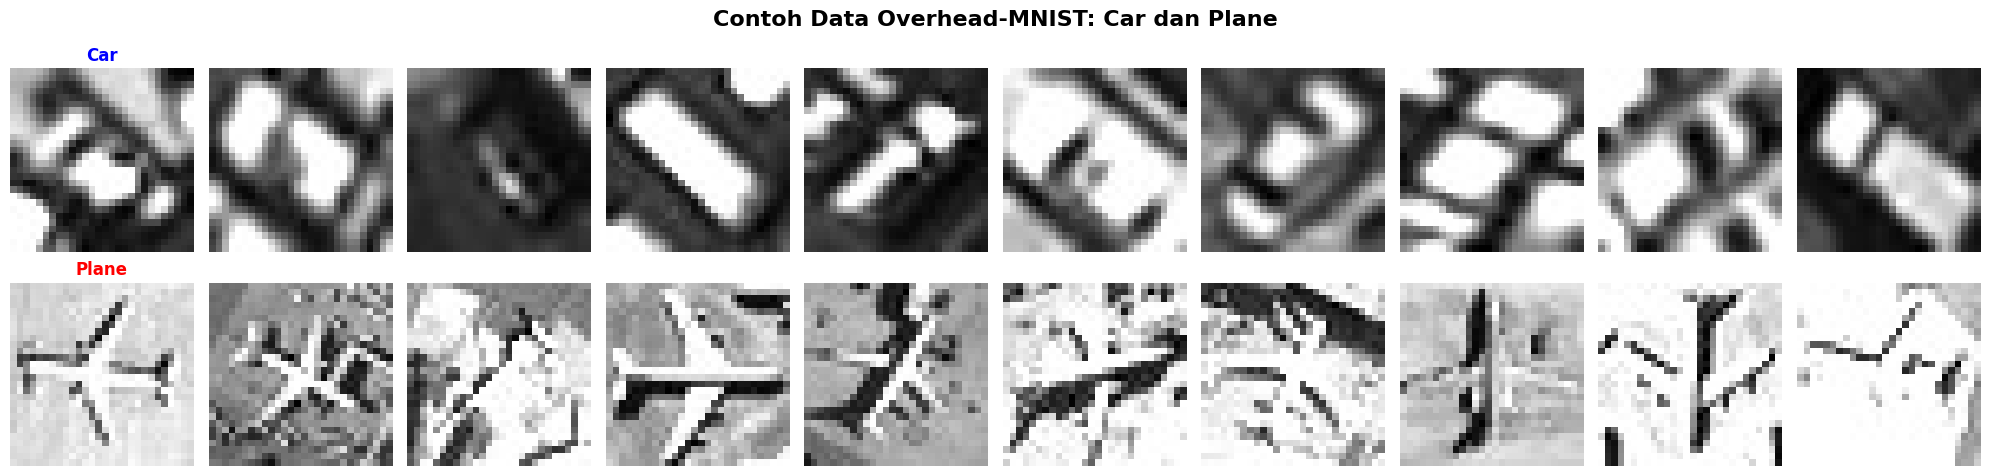

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Contoh Data Overhead-MNIST: Car dan Plane', fontsize=16, fontweight='bold')

car_indices = np.where(y_all == CAR_LABEL)[0][:10]
for i, idx in enumerate(car_indices):
    axes[0, i].imshow(X_all[idx].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Car', fontsize=12, fontweight='bold', color='blue')

plane_indices = np.where(y_all == PLANE_LABEL)[0][:10]
for i, idx in enumerate(plane_indices):
    axes[1, i].imshow(X_all[idx].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Plane', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

Total sampel: 16024
Dimensi per gambar: (28, 28) (784 piksel)

Distribusi kelas:
  Car (label 0): 8012 sampel (50.0%)
  Plane (label 1): 8012 sampel (50.0%)


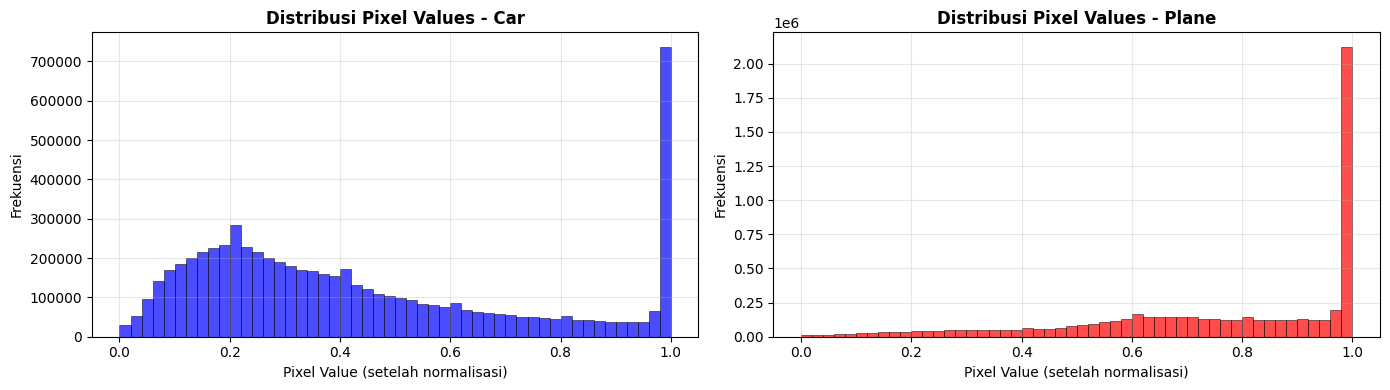

In [7]:
print(f'Total sampel: {len(X_all)}')
print(f'Dimensi per gambar: {X_all.shape[1:]} ({np.prod(X_all.shape[1:])} piksel)')
print(f'\nDistribusi kelas:')
for label, name in [(CAR_LABEL, 'Car'), (PLANE_LABEL, 'Plane')]:
    count = np.sum(y_all == label)
    pct = count / len(y_all) * 100
    print(f'  {name} (label {label}): {count} sampel ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, name, color) in zip(axes, [(CAR_LABEL, 'Car', 'blue'), (PLANE_LABEL, 'Plane', 'red')]):
    mask = y_all == label
    pixel_values = X_all[mask].flatten()
    ax.hist(pixel_values, bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Distribusi Pixel Values - {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Value (setelah normalisasi)')
    ax.set_ylabel('Frekuensi')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Histogram pixel values menunjukkan distribusi intensitas piksel setelah normalisasi [0, 1]. Kelas Car memiliki konsentrasi tinggi di area gelap (nilai rendah, mendekati 0), yang merepresentasikan latar belakang citra satelit. Sedangkan Plane cenderung lebih terang mendekati 1. Perbedaan distribusi antara Car dan Plane mengindikasikan bahwa kedua kelas memiliki karakteristik visual yang cukup berbeda. Oleh karena itu, diperlukan autoencoder yang dapat menangkap pola spasial yang berbeda untuk tiap kelas.

## Reshape Data untuk Convolutional Autoencoder

In [8]:
if len(X_all.shape) == 2 and X_all.shape[1] == 784:
    X_all = X_all.reshape(-1, 28, 28, 1)
elif len(X_all.shape) == 3:
    X_all = X_all.reshape(-1, 28, 28, 1)

print(f'Shape data (reshaped): {X_all.shape}')

Shape data (reshaped): (16024, 28, 28, 1)


## Split Dataset
Karena tugas ini Dimension Reduction (unsupervised), autoencoder dilatih merekonstruksi input (`fit(X, X)`) tanpa memakai label. Label hanya dipakai untuk stratifikasi split dan analisis SSIM per kelas.

In [9]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.10, random_state=42, stratify=y_all
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=1/9, random_state=42, stratify=y_temp
)

print(f'Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X_all)*100:.1f}%)')
print(f'Validation set: {X_val.shape[0]} sampel ({X_val.shape[0]/len(X_all)*100:.1f}%)')
print(f'Test set      : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X_all)*100:.1f}%)')
print(f'\nInput shape per gambar: {X_train.shape[1:]}')

print('\nDistribusi kelas per set:')
for set_name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    car_count   = np.sum(y_set == CAR_LABEL)
    plane_count = np.sum(y_set == PLANE_LABEL)
    print(f'  {set_name}: Car={car_count}, Plane={plane_count}')

Training set  : 12818 sampel (80.0%)
Validation set: 1603 sampel (10.0%)
Test set      : 1603 sampel (10.0%)

Input shape per gambar: (28, 28, 1)

Distribusi kelas per set:
  Train: Car=6409, Plane=6409
  Val: Car=801, Plane=802
  Test: Car=802, Plane=801


# b) Baseline

In [10]:
latent_dim = 128

encoder_input = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)  
x = MaxPooling2D((2, 2))(x)                                               
x = Flatten()(x)                                                          
encoded = Dense(latent_dim, activation='relu')(x)                         
encoder_baseline = Model(encoder_input, encoded)

print('Encoder')
encoder_baseline.summary()

I0000 00:00:1782738254.367960      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782738254.373963      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Encoder


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803,264 (3.06 MB)

 Trainable params: 803,264 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder_input = Input(shape=(latent_dim,))
y = Dense(14 * 14 * 32)(decoder_input)        
y = Reshape((14, 14, 32))(y)                  
y = UpSampling2D((2, 2))(y)                   
y = Conv2D(32, (3, 3), activation='relu', padding='same')(y)              
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(y)      
decoder_baseline = Model(decoder_input, decoded)

print('Decoder')
decoder_baseline.summary()

Decoder


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818,625 (3.12 MB)

 Trainable params: 818,625 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
autoencoder_input = Input(shape=(28, 28, 1))
reconstructed_output = decoder_baseline(encoder_baseline(autoencoder_input))
autoencoder_baseline = Model(autoencoder_input, reconstructed_output)

autoencoder_baseline.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Autoencoder")
autoencoder_baseline.summary()

Autoencoder


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 128)            │       803,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 28, 28, 1)      │       818,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_baseline = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

history_baseline = autoencoder_baseline.fit(
    X_train, X_train,
    epochs=150, batch_size=128, shuffle=True,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_baseline],
    verbose=1
)

Epoch 1/150


I0000 00:00:1782738257.768554     133 service.cc:152] XLA service 0x7fe2e000e940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782738257.768614     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782738257.768621     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782738258.132322     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 25/101 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0992

I0000 00:00:1782738261.054132     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0620 - val_loss: 0.0395
Epoch 2/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0312 - val_loss: 0.0269
Epoch 3/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0242 - val_loss: 0.0228
Epoch 4/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0209 - val_loss: 0.0200
Epoch 5/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0188 - val_loss: 0.0184
Epoch 6/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0178 - val_loss: 0.0180
Epoch 7/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0175 - val_loss: 0.0178
Epoch 8/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0171 - val_loss: 0.0173
Epoch 9/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0167 - val_loss: 0.0169
Epoch 10/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0164 - val_loss: 0.0168
Epoch 11/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0162 - val_loss: 0.0165
Epoch 12/150
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

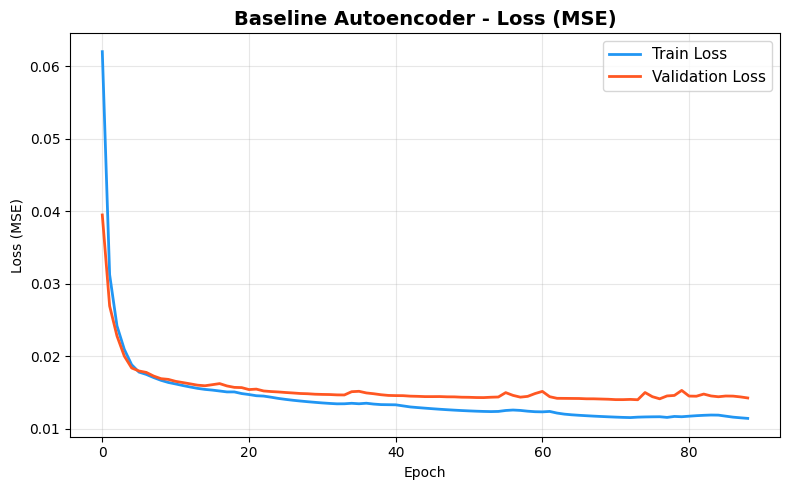

In [14]:
h = history_baseline.history
plt.figure(figsize=(8, 5))
plt.plot(h['loss'],     label='Train Loss', linewidth=2, color='#2196F3')
plt.plot(h['val_loss'], label='Validation Loss', linewidth=2, color='#FF5722')
plt.title('Baseline Autoencoder - Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Dari grafik loss terlihat train dan validation loss turun bersamaan dan mulai mendatar di sekitar epoch 20. Setelah itu, tampak validation loss yang mulai mendatar sedangkan training loss tetap turun perlahan sehingga menimbulkan gap kecil. Ini menunjukkan potensi overfitting jika ditraining lebih lanjut. Namun, karena sudah diterapkan early stop, maka model yang disimpan adalah model yang belum overfitting. Model tampak belajar cukup baik, namun untuk mengevaluasi kinerja autoencoder lebih lanjut, kita perlu membandingkan metrik SSIM nya.

In [15]:
def calculate_ssim(original, reconstructed, image_shape=(28, 28)):
    ssim_scores = []
    for i in range(len(original)):
        orig_img = original[i].reshape(image_shape)
        recon_img = reconstructed[i].reshape(image_shape)
        score = ssim(orig_img, recon_img, data_range=1.0)
        ssim_scores.append(score)
    return np.mean(ssim_scores), ssim_scores

In [ ]:
X_test_reconstructed_baseline = autoencoder_baseline.predict(X_test, verbose=0)
mean_ssim_baseline, ssim_scores_baseline = calculate_ssim(X_test, X_test_reconstructed_baseline)

print(f'Rata-rata SSIM: {mean_ssim_baseline:.6f}')

for label, name in [(CAR_LABEL, 'Car'), (PLANE_LABEL, 'Plane')]:
    mask = y_test == label
    class_ssim = [ssim_scores_baseline[i] for i in range(len(y_test)) if mask[i]]
    print(f'\nSSIM {name}: {np.mean(class_ssim):.6f} (±{np.std(class_ssim):.6f})')

Rata-rata SSIM: 0.701744

SSIM Car: 0.807871 (±0.082734)

SSIM Plane: 0.595484 (±0.138610)


Rata-rata SSIM (Structural Similarity Index) pada model baseline cukup tinggi, yaitu sekitar 0.70. Namun, terdapat perbedaan nilai SSIM antar kelas, dimana kelas Car mencapai sekitar 0.80, sedangkan kelas Plane hanya berada di kisaran 0.59. Hal ini menunjukkan bahwa model lebih mampu mempertahankan kemiripan struktur visual pada kelas Car dibandingkan kelas Plane.

Perbedaan tersebut dapat disebabkan oleh karakteristik objek pesawat pada citra overhead yang memiliki bentuk tipis dan diagonal (badan serta sayap), sehingga lebih sulit direpresentasikan oleh encoder sederhana yang hanya menggunakan satu Conv layer. Sebaliknya, mobil memiliki bentuk yang cenderung lebih kompak dan berpola kotak sehingga lebih mudah dipelajari oleh model. Selain itu, standar deviasi kelas Plane (0.139) yang lebih tinggi dibandingkan Car (0.083) menunjukkan bahwa kualitas rekonstruksi pada kelas Plane kurang konsisten, dimana sebagian citra dapat direkonstruksi dengan baik sementara sebagian lainnya mengalami penurunan kualitas yang cukup signifikan.

Oleh karena itu, pada arsitektur modifikasi ditambahkan Conv layer kedua pada encoder untuk memperkaya ekstraksi fitur spasial tanpa menghilangkan detail penting. Perubahan serupa juga diterapkan pada decoder dengan menambahkan Conv layer sebelum proses UpSampling, sehingga decoder memiliki kapasitas yang seimbang dalam memanfaatkan fitur yang telah dipelajari encoder saat melakukan rekonstruksi. Selain itu, BatchNormalization ditambahkan setelah setiap Conv layer (sebelum aktivasi) untuk membantu menstabilkan proses training dan memberikan regularisasi ringan.

In [ ]:
def plot_reconstruction(original, reconstructed, labels, car_label, plane_label,
                        n_samples=8, title='Rekonstruksi Autoencoder'):
    fig, axes = plt.subplots(4, n_samples, figsize=(2.5 * n_samples, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)

    car_idx = np.where(labels == car_label)[0][:n_samples]
    for i, idx in enumerate(car_idx):
        axes[0, i].imshow(original[idx].reshape(28, 28), cmap='gray')
        axes[1, i].imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        
        for row in [0, 1]:
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])
            for spine in axes[row, i].spines.values():
                spine.set_visible(False)
        
        if i == 0:
            axes[0, i].set_ylabel('Car\n(Original)', fontsize=12, fontweight='bold', labelpad=15)
            axes[1, i].set_ylabel('Car\n(Rekon)', fontsize=12, fontweight='bold', labelpad=15)

    plane_idx = np.where(labels == plane_label)[0][:n_samples]
    for i, idx in enumerate(plane_idx):
        axes[2, i].imshow(original[idx].reshape(28, 28), cmap='gray')
        axes[3, i].imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        
        for row in [2, 3]:
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])
            for spine in axes[row, i].spines.values():
                spine.set_visible(False)
        
        if i == 0:
            axes[2, i].set_ylabel('Plane\n(Original)', fontsize=12, fontweight='bold', labelpad=15)
            axes[3, i].set_ylabel('Plane\n(Rekon)', fontsize=12, fontweight='bold', labelpad=15)

    plt.tight_layout()
    plt.show()

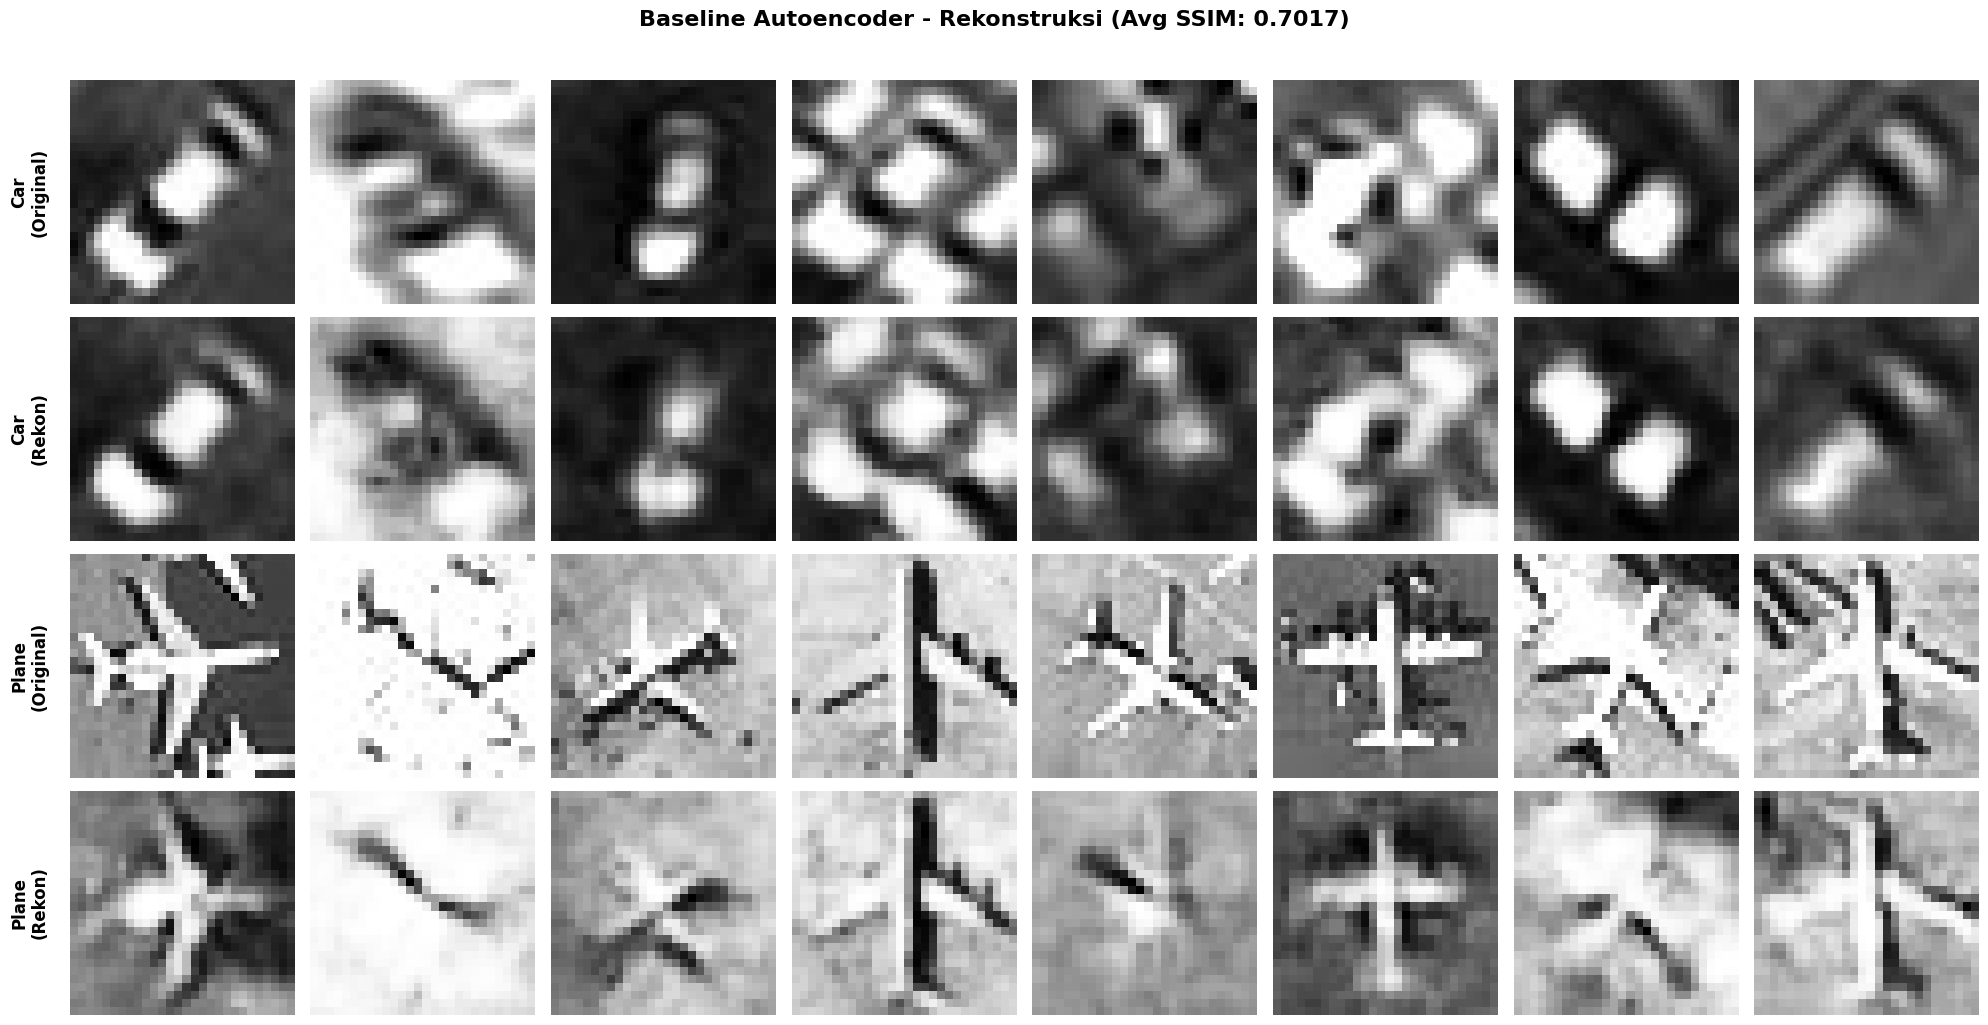

In [19]:
plot_reconstruction(
    X_test, X_test_reconstructed_baseline, y_test,
    CAR_LABEL, PLANE_LABEL, n_samples=8,
    title=f'Baseline Autoencoder - Rekonstruksi (Avg SSIM: {mean_ssim_baseline:.4f})'
)

Terlihat bahwa gambar hasil rekonstruksi Car sudah cukup mirip dengan data originalnya. Namun, berbeda dengan Plane yang tampak lebih buram dibandingkan gambar aslinya.

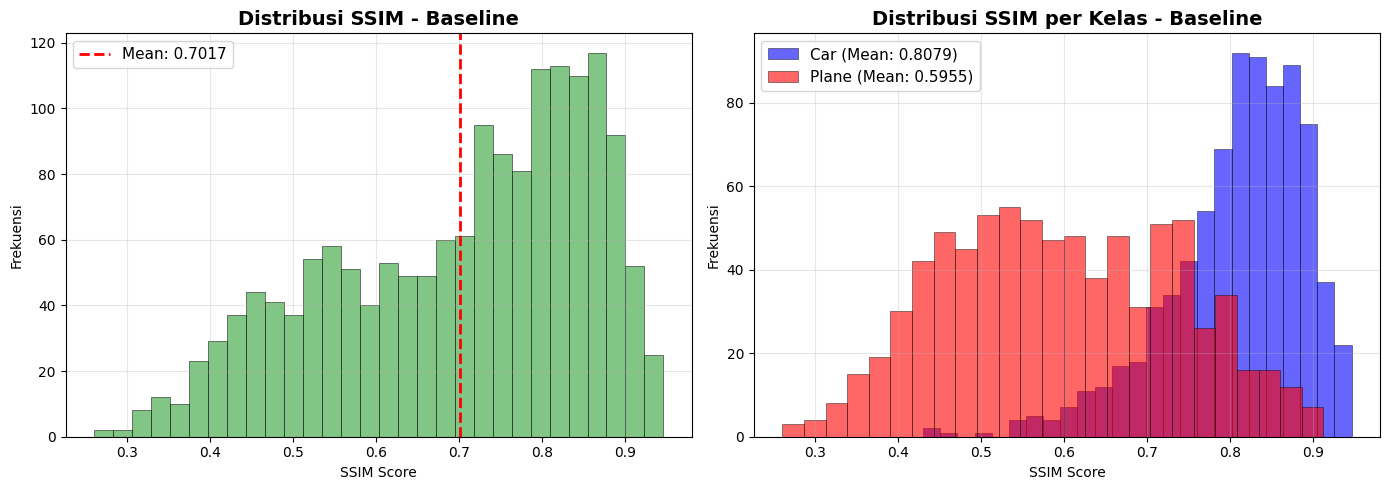

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ssim_scores_baseline, bins=30, color='#4CAF50', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(mean_ssim_baseline, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_ssim_baseline:.4f}')
axes[0].set_title('Distribusi SSIM - Baseline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SSIM Score'); axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

car_ssim = [ssim_scores_baseline[i] for i in range(len(y_test)) if y_test[i] == CAR_LABEL]
plane_ssim = [ssim_scores_baseline[i] for i in range(len(y_test)) if y_test[i] == PLANE_LABEL]

axes[1].hist(car_ssim, bins=25, color='blue', alpha=0.6,
             label=f'Car (Mean: {np.mean(car_ssim):.4f})', edgecolor='black', linewidth=0.5)
axes[1].hist(plane_ssim, bins=25, color='red', alpha=0.6,
             label=f'Plane (Mean: {np.mean(plane_ssim):.4f})', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi SSIM per Kelas - Baseline', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SSIM Score'); axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Terlihat bahwa distribusi masih banyak yang berada pada SSIM score rendah terutama class Plane sehingga perlu modifikasi arsitektur lebih lanjut.

# c) Modification & Hyperparameter Tuning

In [ ]:
def build_improved_autoencoder(latent_dim=128):
    #Encoder
    inp = Input(shape=(28, 28, 1))
    x = Conv2D(32, 3, padding='same')(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                                       
    x = Conv2D(32, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)  
    x = Flatten()(x)                                            
    latent = Dense(latent_dim, activation='relu')(x)           
    encoder = Model(inp, latent, name='encoder_mod')

    # Decoder
    dinp = Input(shape=(latent_dim,))
    y = Dense(14 * 14 * 32, activation='relu')(dinp)
    y = Reshape((14, 14, 32))(y)
    y = Conv2D(32, 3, padding='same')(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)   
    y = UpSampling2D(2)(y)                                      
    y = Conv2D(32, 3, padding='same')(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    out = Conv2D(1, 3, activation='sigmoid', padding='same')(y)
    decoder = Model(dinp, out, name='decoder_mod')

    ae_in = Input(shape=(28, 28, 1))
    ae = Model(ae_in, decoder(encoder(ae_in)), name='autoencoder_mod')
    return ae, encoder

mod_ae, mod_encoder = build_improved_autoencoder(128)
mod_ae.summary()
print(f'\nParameter baseline  : {autoencoder_baseline.count_params():,}')
print(f'Parameter modifikasi: {mod_ae.count_params():,}')

Model: "autoencoder_mod"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_mod (Functional)        │ (None, 128)            │       812,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_mod (Functional)        │ (None, 28, 28, 1)      │       828,129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,640,897 (6.26 MB)

 Trainable params: 1,640,641 (6.26 MB)

 Non-trainable params: 256 (1.00 KB)


Parameter baseline  : 1,621,889
Parameter modifikasi: 1,640,897


In [22]:
mod_ae.compile(optimizer=Adam(1e-3), loss='mse')
es_mod = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history_mod = mod_ae.fit(
    X_train, X_train, epochs=80, batch_size=128, shuffle=True,
    validation_data=(X_val, X_val), callbacks=[es_mod], verbose=1
)


Epoch 1/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 0.0391 - val_loss: 0.1030
Epoch 2/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0193 - val_loss: 0.1140
Epoch 3/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0151 - val_loss: 0.0914
Epoch 4/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0135 - val_loss: 0.0459
Epoch 5/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0126 - val_loss: 0.0192
Epoch 6/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0119 - val_loss: 0.0130
Epoch 7/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0114 - val_loss: 0.0129
Epoch 8/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0111 - val_loss: 0.0135
Epoch 9/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0108 - val_loss: 0.0131
Epoch 10/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0107 - val_loss: 0.0126
Epoch 11/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0105 - val_loss: 0.0122
Epoch 12/80
101/101 ━━━━━━━━━━━━━━━━━━━━

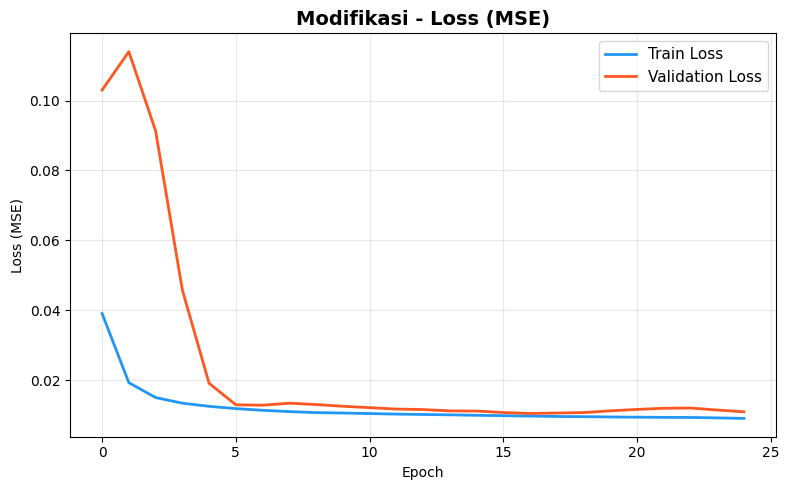

In [23]:
h = history_mod.history
plt.figure(figsize=(8, 5))
plt.plot(h['loss'],     label='Train Loss', linewidth=2, color='#2196F3')
plt.plot(h['val_loss'], label='Validation Loss', linewidth=2, color='#FF5722')
plt.title('Modifikasi - Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Grafik loss menunjukkan train loss dan validation loss yang konvergen serta stabil dengan cepat di sekitar epoch 15. Tidak lagi terlihat gap yang signifikan seperti pada model baseline, yang menunjukkan bahwa model lebih mampu mempelajari representasi data secara efektif tanpa mengalami overfitting maupun underfitting yang berarti.

Selain itu, kedua kurva memiliki pola yang relatif sejajar dan konsisten hingga akhir training, menandakan bahwa penambahan Conv layer dan BatchNormalization berhasil meningkatkan stabilitas proses pembelajaran serta kemampuan generalisasi model.

In [36]:
recon_mod = mod_ae.predict(X_test, verbose=0)
mean_ssim_mod, ssim_scores_mod = calculate_ssim(X_test, recon_mod)

car_mod    = np.mean([ssim_scores_mod[i]      for i in range(len(y_test)) if y_test[i] == CAR_LABEL])
plane_mod  = np.mean([ssim_scores_mod[i]      for i in range(len(y_test)) if y_test[i] == PLANE_LABEL])
car_base   = np.mean([ssim_scores_baseline[i] for i in range(len(y_test)) if y_test[i] == CAR_LABEL])
plane_base = np.mean([ssim_scores_baseline[i] for i in range(len(y_test)) if y_test[i] == PLANE_LABEL])

results_2c = [{'lr': 1e-3, 'ssim': mean_ssim_mod, 'car': car_mod, 'plane': plane_mod,
               'history': history_mod.history, 'model': mod_ae}]

df_results = pd.DataFrame({
    'Model': ['Baseline (2b)', 'Modif (lr=1e-3)'],
    'SSIM': [mean_ssim_baseline, mean_ssim_mod],
    'Car': [car_base, car_mod],
    'Plane': [plane_base, plane_mod]
})

delta = pd.DataFrame({
    'Model': ['Selisih'],
    'SSIM': [mean_ssim_mod - mean_ssim_baseline],
    'Car': [car_mod - car_base],
    'Plane': [plane_mod - plane_base]
}).round(4)

df_results = pd.concat([df_results, delta], ignore_index=True)

df_results

,Model,SSIM,Car,Plane
0,Baseline (2b),0.701744,0.807871,0.595484
1,Modif (lr=1e-3),0.772647,0.884890,0.660264
2,Selisih,0.070900,0.077000,0.064800


Dari nilai SSIM juga terlihat adanya peningkatan sekitar 0.071 dibandingkan model Baseline. Meskipun peningkatannya tidak terlalu besar, model sudah lebih mampu mempertahankan kemiripan struktur visual antara citra hasil rekonstruksi dan citra asli.

Hasil ini menunjukkan bahwa penambahan Conv layer dan BatchNormalization berhasil memperkaya ekstraksi fitur spasial, terutama pada objek dengan pola yang lebih kompleks seperti pesawat. Namun, nilai SSIM kelas Plane yang masih berada di kisaran 0.66 dibandingkan Car yang mencapai 0.88 menunjukkan bahwa masih terdapat ruang untuk peningkatan performa melalui proses tuning hyperparameter pada tahap berikutnya.

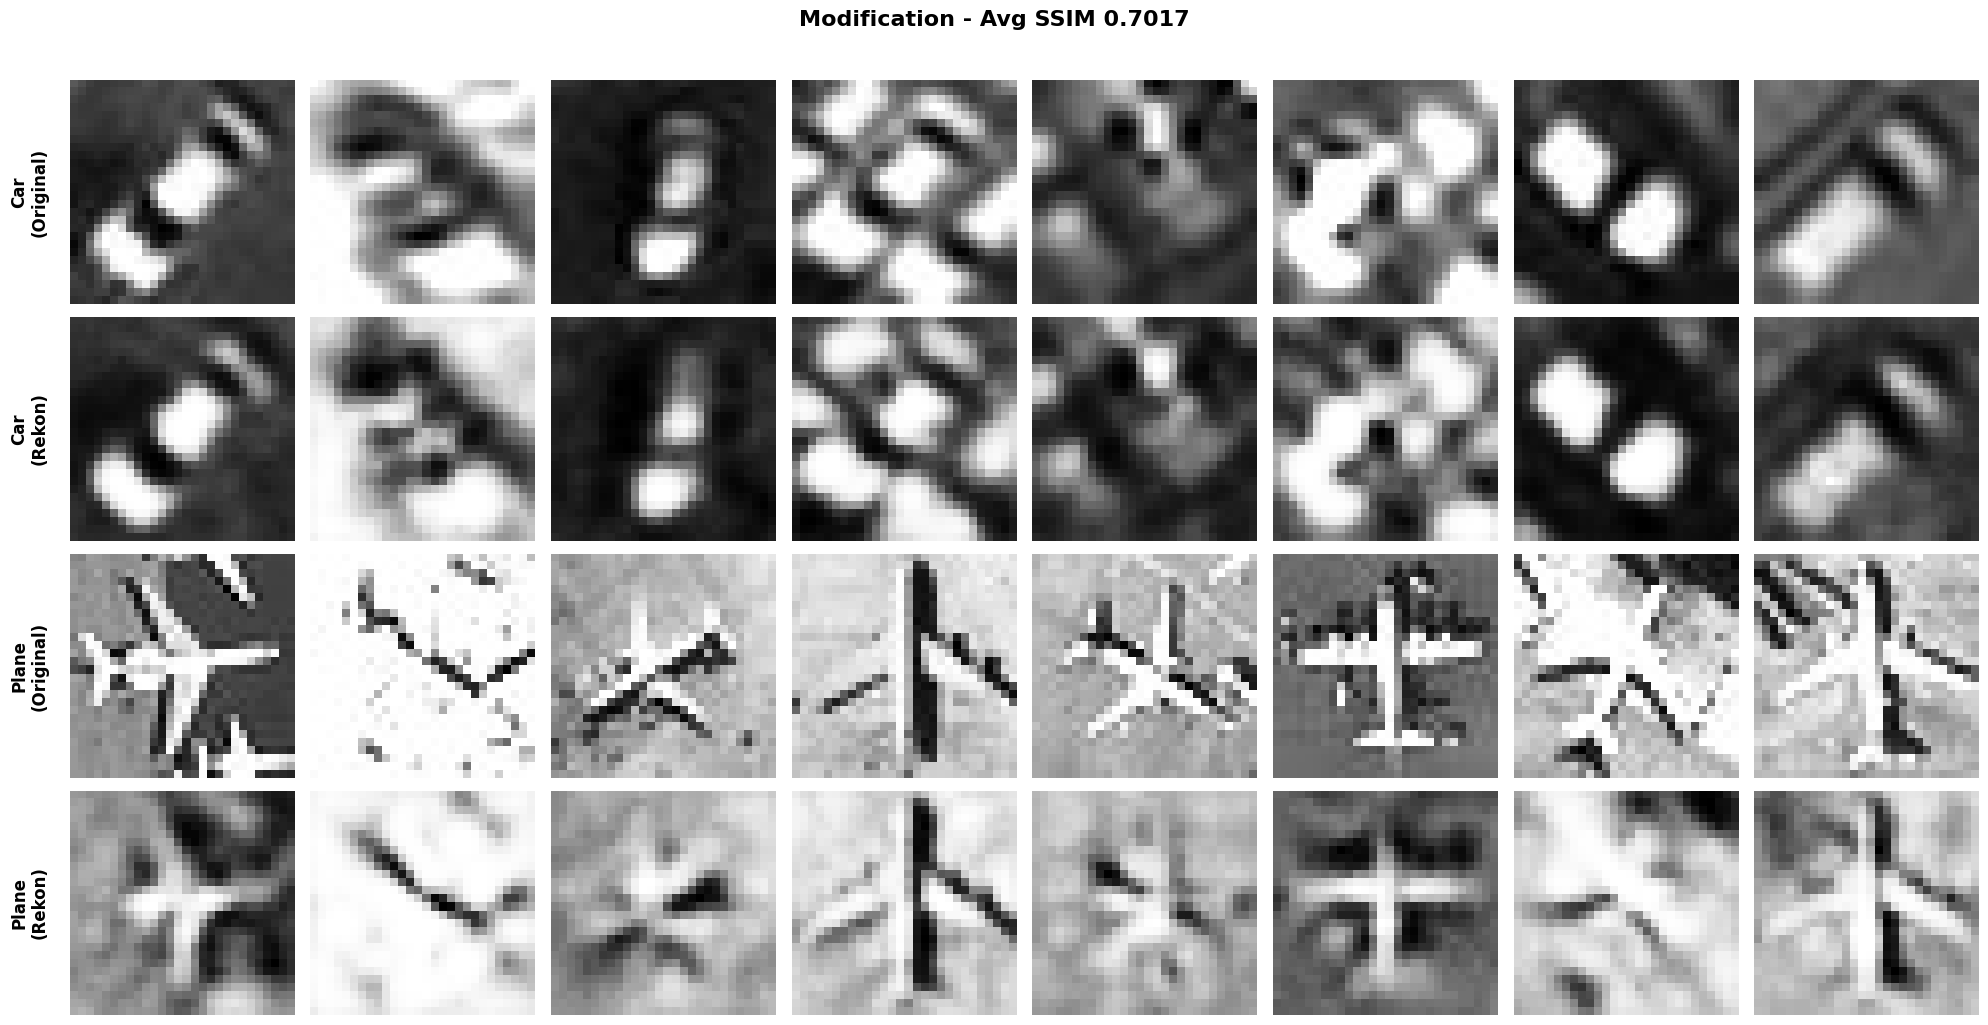

In [ ]:

plot_reconstruction(
    X_test, recon_mod, y_test, CAR_LABEL, PLANE_LABEL, n_samples=8,
    title=f'Modification - Avg SSIM {mean_ssim_mod:.4f}'
)

Hasil gambar rekonstruksi sedikit membaik dibandingkan model baseline meskipun belum optimal

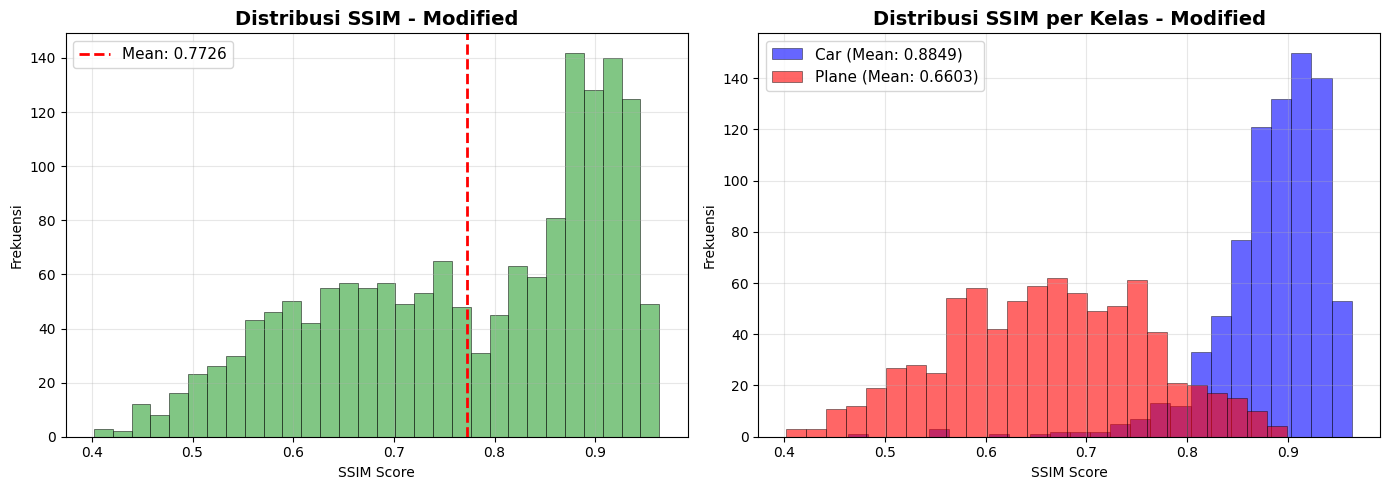

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ssim_scores_mod, bins=30, color='#4CAF50', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(mean_ssim_mod, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_ssim_mod:.4f}')
axes[0].set_title('Distribusi SSIM - Modified', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SSIM Score'); axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

car_ssim_mod = [ssim_scores_mod[i] for i in range(len(y_test)) if y_test[i] == CAR_LABEL]
plane_ssim_mod = [ssim_scores_mod[i] for i in range(len(y_test)) if y_test[i] == PLANE_LABEL]

axes[1].hist(car_ssim_mod, bins=25, color='blue', alpha=0.6,
             label=f'Car (Mean: {np.mean(car_ssim_mod):.4f})', edgecolor='black', linewidth=0.5)
axes[1].hist(plane_ssim_mod, bins=25, color='red', alpha=0.6,
             label=f'Plane (Mean: {np.mean(plane_ssim_mod):.4f})', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi SSIM per Kelas - Modified', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SSIM Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Distribusi SSIM pada model modifikasi menunjukkan perbaikan dibandingkan baseline, yang ditandai dengan pergeseran histogram ke arah nilai SSIM yang lebih tinggi dan berkurangnya jumlah sampel dengan SSIM rendah. Perbaikan ini terlihat terutama pada kelas Plane, dimana distribusinya menjadi lebih tinggi dan lebih konsisten sehingga gap dengan kelas Car semakin mengecil. Hasil ini menunjukkan bahwa penambahan Conv layer dan BatchNormalization berhasil meningkatkan kualitas rekonstruksi, khususnya pada kelas yang sebelumnya menjadi kelemahan model baseline.

### Hyperparameter Tuning
Parameter yang akan dituning adalah **learning rate**. Hal ini karena learning rate merupakan salah satu hyperparameter pelatihan yang paling berpengaruh terhadap kualitas konvergensi model. Nilai learning rate menentukan seberapa besar langkah pembaruan bobot pada setiap iterasi training. Jika learning rate terlalu besar, proses training dapat menjadi tidak stabil dan sulit mencapai solusi optimal. Sebaliknya, jika terlalu kecil, proses pembelajaran menjadi lambat dan model berisiko terjebak pada solusi yang kurang baik. Oleh karena itu, pemilihan learning rate yang tepat penting untuk memperoleh keseimbangan antara kecepatan konvergensi, stabilitas training, dan kualitas hasil rekonstruksi yang dihasilkan.

In [37]:
for lr in [5e-4, 1e-4]:
    print(f'\n{"="*55}\nlearning_rate = {lr}\n{"="*55}')
    tf.keras.backend.clear_session()
    ae, _ = build_improved_autoencoder(128)
    ae.compile(optimizer=Adam(lr), loss='mse')
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    hist = ae.fit(X_train, X_train, epochs=80, batch_size=128, shuffle=True,
                  validation_data=(X_val, X_val), callbacks=[es], verbose=0)
    recon = ae.predict(X_test, verbose=0)
    m, sc = calculate_ssim(X_test, recon)
    cs = np.mean([sc[i] for i in range(len(y_test)) if y_test[i] == CAR_LABEL])
    ps = np.mean([sc[i] for i in range(len(y_test)) if y_test[i] == PLANE_LABEL])
    results_2c.append({'lr': lr, 'ssim': m, 'car': cs, 'plane': ps,
                       'history': hist.history, 'model': ae})
    print(f'  SSIM={m:.4f} | Car={cs:.4f} | Plane={ps:.4f} | stop@epoch {len(hist.history["loss"])}')

results_2c.sort(key=lambda r: -r['lr'])
best = max(results_2c, key=lambda r: r['ssim'])
print(f'\n>> learning_rate terbaik: {best["lr"]} (SSIM={best["ssim"]:.4f})')


learning_rate = 0.0005
  SSIM=0.7856 | Car=0.8950 | Plane=0.6760 | stop@epoch 22

learning_rate = 0.0001
  SSIM=0.8543 | Car=0.9383 | Plane=0.7702 | stop@epoch 80

>> learning_rate terbaik: 0.0001 (SSIM=0.8543)


            Model     lr   SSIM    Car  Plane
         Baseline      - 0.7017 0.8079 0.5955
 Modif (lr=0.001) 0.0010 0.7726 0.8849 0.6603
Modif (lr=0.0005) 0.0005 0.7856 0.8950 0.6760
Modif (lr=0.0001) 0.0001 0.8543 0.9383 0.7702

Baseline -> Terbaik (lr=0.0001): SSIM 0.7017 -> 0.8543 (+0.1526)


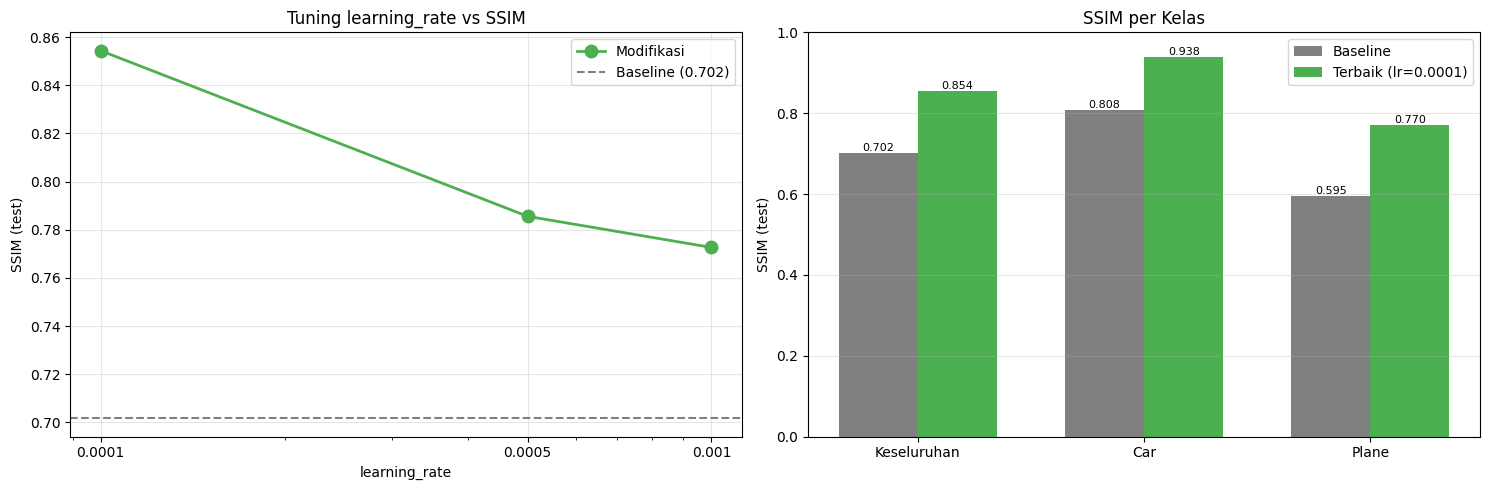

In [38]:
rows = [{'Model': 'Baseline', 'lr': '-', 'SSIM': mean_ssim_baseline,
         'Car': car_base, 'Plane': plane_base}]
for r in results_2c:
    rows.append({'Model': f'Modif (lr={r["lr"]:g})', 'lr': r['lr'],
                 'SSIM': r['ssim'], 'Car': r['car'], 'Plane': r['plane']})
df = pd.DataFrame(rows)[['Model', 'lr', 'SSIM', 'Car', 'Plane']]
print(df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\nBaseline -> Terbaik (lr={best["lr"]:g}): '
      f'SSIM {mean_ssim_baseline:.4f} -> {best["ssim"]:.4f} ({best["ssim"]-mean_ssim_baseline:+.4f})')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

lrs = [r['lr'] for r in results_2c]; ss = [r['ssim'] for r in results_2c]
axes[0].plot(lrs, ss, 'o-', linewidth=2, markersize=9, color='#4CAF50', label='Modifikasi')
axes[0].axhline(mean_ssim_baseline, color='gray', linestyle='--',
                label=f'Baseline ({mean_ssim_baseline:.3f})')
axes[0].set_xscale('log'); axes[0].set_xlabel('learning_rate'); axes[0].set_ylabel('SSIM (test)')
axes[0].set_title('Tuning learning_rate vs SSIM'); axes[0].set_xticks(lrs)
axes[0].set_xticklabels([f'{v:g}' for v in lrs]); axes[0].legend(); axes[0].grid(True, alpha=0.3)

labels = ['Keseluruhan', 'Car', 'Plane']
base_vals = [mean_ssim_baseline, car_base, plane_base]
best_vals = [best['ssim'], best['car'], best['plane']]
x = np.arange(len(labels)); w = 0.35
b1 = axes[1].bar(x - w/2, base_vals, w, label='Baseline', color='gray')
b2 = axes[1].bar(x + w/2, best_vals, w, label=f'Terbaik (lr={best["lr"]:g})', color='#4CAF50')
axes[1].bar_label(b1, fmt='%.3f', fontsize=8); axes[1].bar_label(b2, fmt='%.3f', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_ylim(0, 1)
axes[1].set_ylabel('SSIM (test)'); axes[1].set_title('SSIM per Kelas')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Terlihat bahwa learning rate 0.0001 (1e-4) menghasilkan nilai SSIM tertinggi sebesar 0.8543. Pada model modifikasi sebelumnya digunakan optimizer Adam dengan learning rate default 1e-3, yang ternyata masih terlalu besar untuk kasus ini. Learning rate yang lebih kecil memungkinkan model melakukan pembaruan bobot secara lebih bertahap sehingga proses pembelajaran menjadi lebih stabil dan tidak mudah melewati solusi yang optimal. Dengan demikian, model dapat mempelajari representasi fitur yang lebih baik dan menghasilkan kualitas rekonstruksi yang lebih mendekati citra asli.

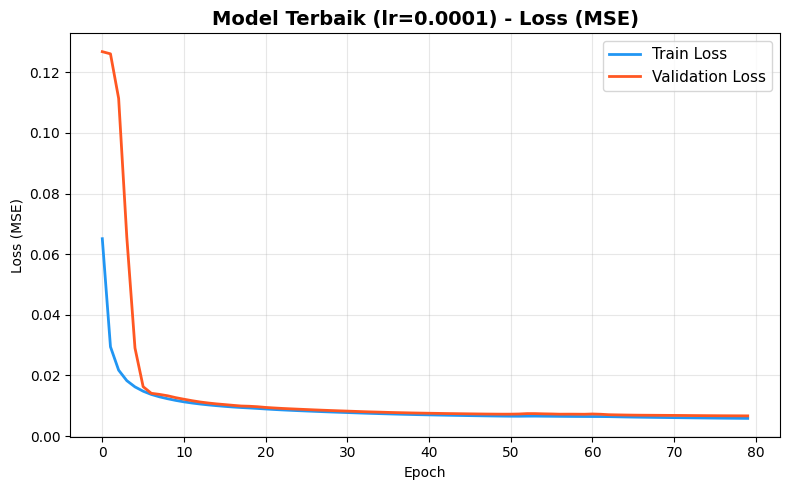

In [39]:
h = best['history']
plt.figure(figsize=(8, 5))
plt.plot(h['loss'],     label='Train Loss', linewidth=2, color='#2196F3')
plt.plot(h['val_loss'], label='Validation Loss', linewidth=2, color='#FF5722')
plt.title(f'Model Terbaik (lr={best["lr"]:g}) - Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Dari grafik loss juga terlihat bahwa model modifikasi dengan learning rate 1e-4 memiliki kurva training loss dan validation loss yang sudah saling berhimpit sejak sekitar epoch 9 dan tetap sejajar hingga akhir proses pelatihan (epoch 80). Kondisi ini menunjukkan bahwa model mampu belajar secara stabil tanpa indikasi overfitting yang berarti. Kombinasi Batch Normalization dan learning rate yang lebih kecil membantu menstabilkan proses optimasi, mengurangi fluktuasi pembaruan bobot, serta memberikan efek regularisasi yang cukup sehingga model dapat mencapai performa yang lebih baik dan lebih konsisten pada data validasi.

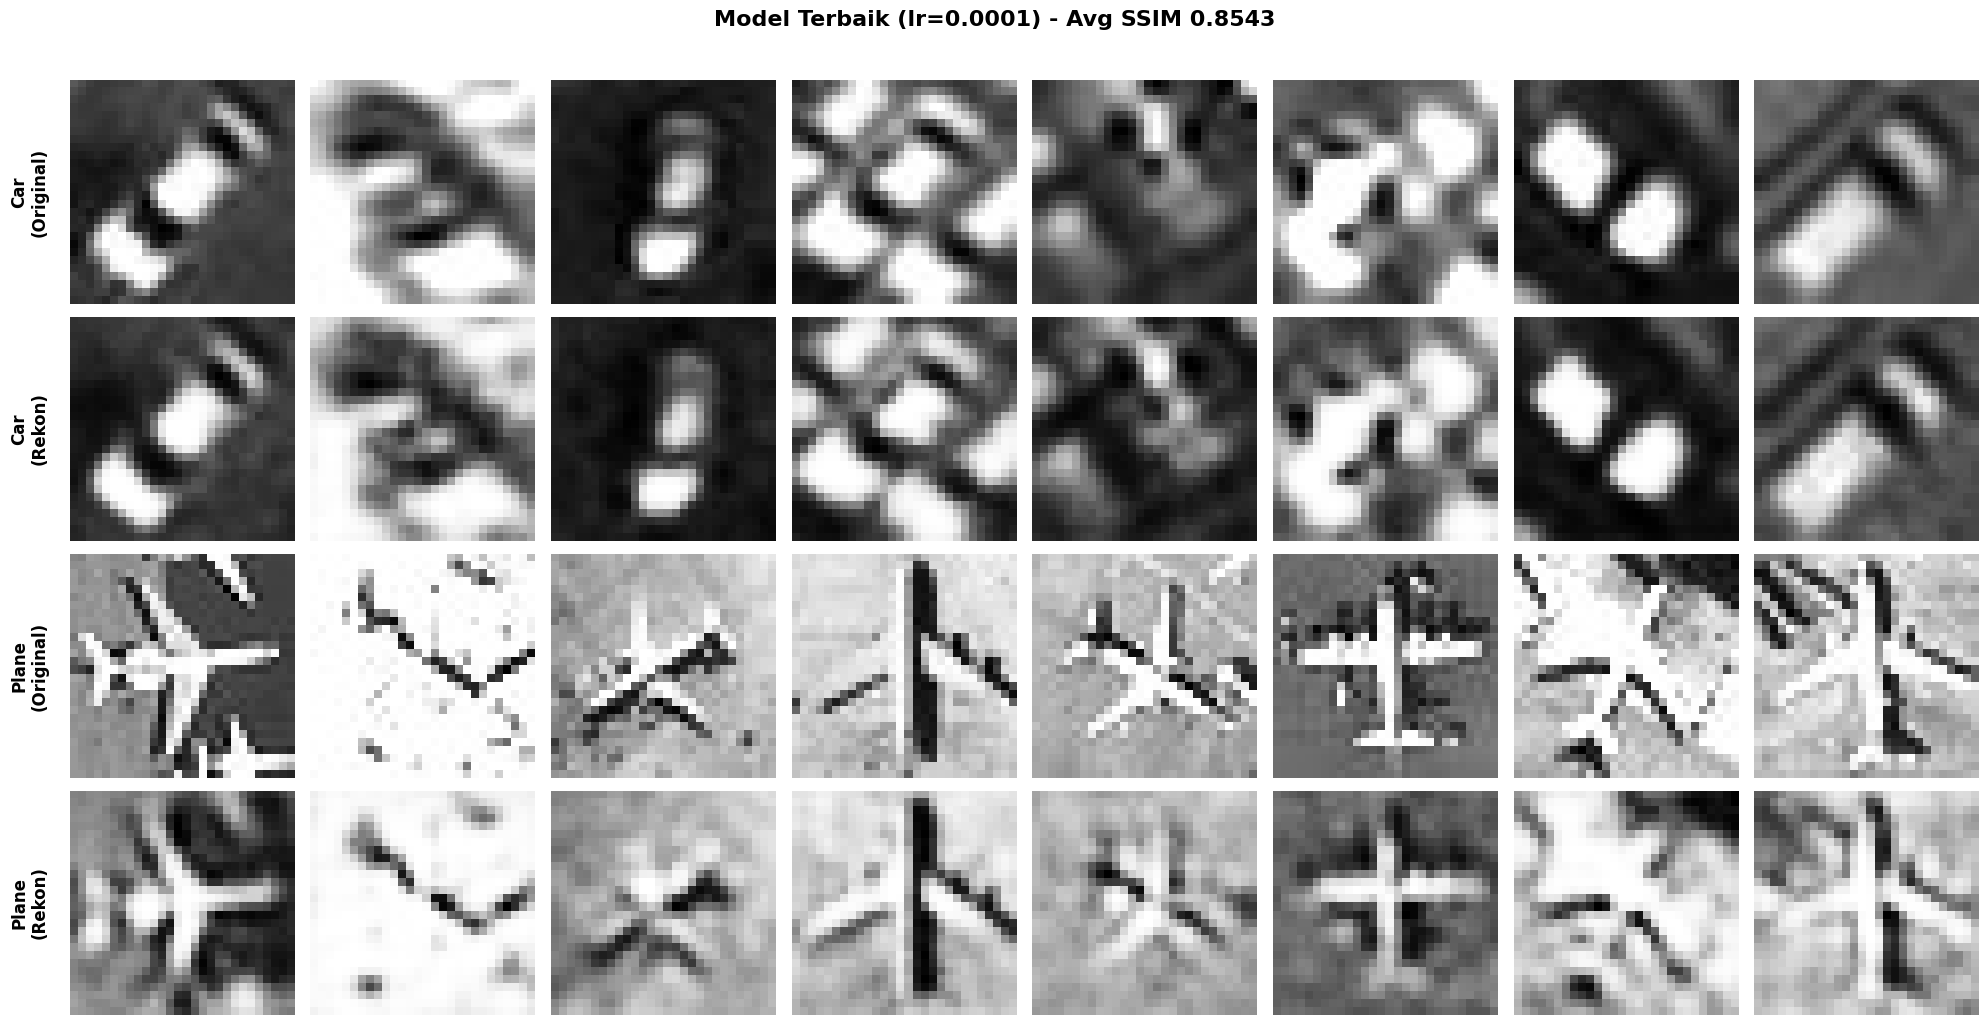

In [40]:
best_recon = best['model'].predict(X_test, verbose=0)
plot_reconstruction(
    X_test, best_recon, y_test, CAR_LABEL, PLANE_LABEL, n_samples=8,
    title=f'Model Terbaik (lr={best["lr"]:g}) - Avg SSIM {best["ssim"]:.4f}'
)

Hasil gambar rekonstruksi lebih terlihat jelas dibandingkan modified dengan learning rate yang lebih rendah menunjukkan autoencoder mampu merekonstruksi gambar dengan baik.

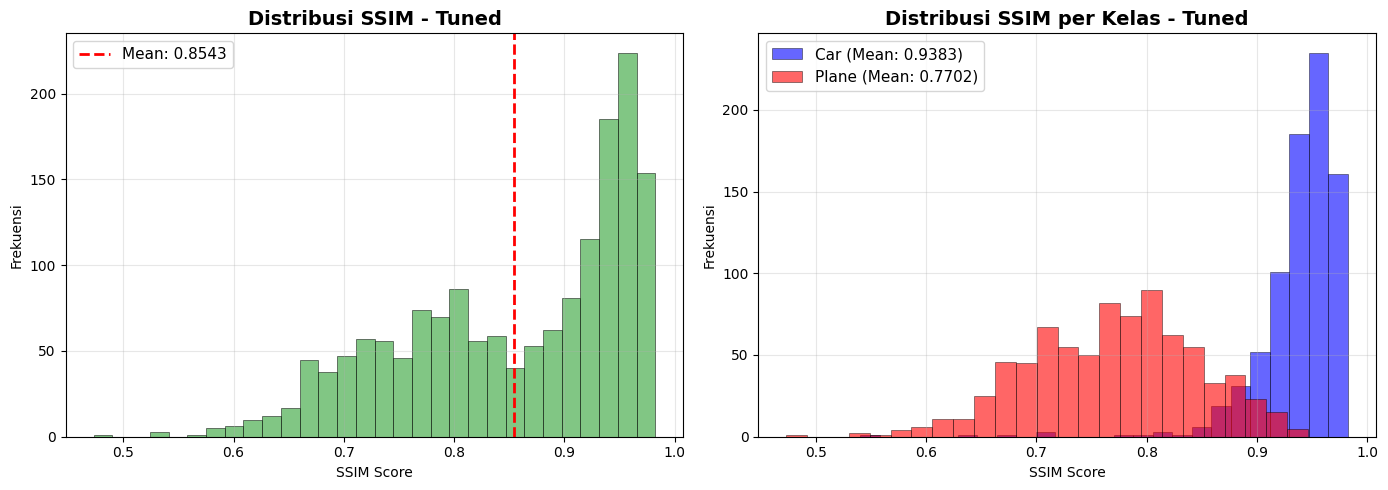

In [41]:
mean_ssim_tuned, ssim_scores_tuned = calculate_ssim(X_test, best_recon)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ssim_scores_tuned, bins=30, color='#4CAF50', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(mean_ssim_tuned, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_ssim_tuned:.4f}')
axes[0].set_title('Distribusi SSIM - Tuned', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SSIM Score'); axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

car_ssim_tuned = [ssim_scores_tuned[i] for i in range(len(y_test)) if y_test[i] == CAR_LABEL]
plane_ssim_tuned = [ssim_scores_tuned[i] for i in range(len(y_test)) if y_test[i] == PLANE_LABEL]

axes[1].hist(car_ssim_tuned, bins=25, color='blue', alpha=0.6,
             label=f'Car (Mean: {np.mean(car_ssim_tuned):.4f})', edgecolor='black', linewidth=0.5)
axes[1].hist(plane_ssim_tuned, bins=25, color='red', alpha=0.6,
             label=f'Plane (Mean: {np.mean(plane_ssim_tuned):.4f})', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi SSIM per Kelas - Tuned', fontsize=14, fontweight='bold')
axes[1].set_xlabel('SSIM Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Distribusi SSIM model terbaik hasil tuning bergeser ke nilai yang lebih tinggi, menunjukkan peningkatan kualitas rekonstruksi pada sebagian besar sampel. Sampel dengan SSIM rendah hampir tidak ditemukan lagi (tidak sebanyak sebelumnya), menandakan performa model yang lebih konsisten. Selain itu, perbedaan kualitas rekonstruksi antar kelas juga berkurang secara signifikan, sehingga model mampu menghasilkan performa yang lebih merata pada berbagai jenis data.

In [ ]:
tahap = [
    ('Baseline', mean_ssim_baseline, car_base, plane_base),
    ('Modif Arsitektur', mean_ssim_mod, car_mod, plane_mod),
    (f'Modif + Tuning (lr={best["lr"]:g})', best['ssim'], best['car'], best['plane']),
]

df_final = pd.DataFrame(tahap, columns=['Tahap', 'SSIM', 'Car', 'Plane'])
df_final['Selisih dengan Baseline'] = df_final['SSIM'] - mean_ssim_baseline
df_final

,Tahap,SSIM,Car,Plane,Selisih dengan Baseline
0,Baseline,0.701744,0.807871,0.595484,0.000000
1,Modif Arsitektur,0.772647,0.884890,0.660264,0.070904
2,Modif + Tuning (lr=0.0001),0.854338,0.938347,0.770225,0.152595


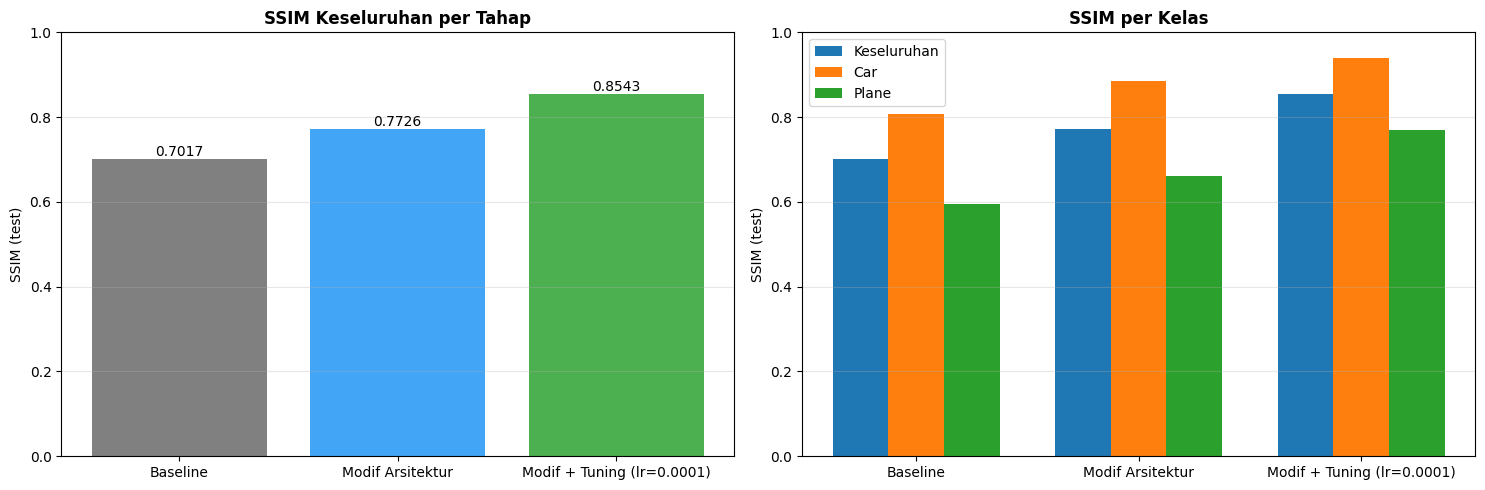

In [43]:
names      = [t[0] for t in tahap]
ssim_all   = [t[1] for t in tahap]
ssim_car   = [t[2] for t in tahap]
ssim_plane = [t[3] for t in tahap]
colors = ['gray', '#42A5F5', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

b = axes[0].bar(range(len(names)), ssim_all, color=colors)
axes[0].bar_label(b, fmt='%.4f', fontsize=10)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names)
axes[0].set_ylabel('SSIM (test)'); axes[0].set_title('SSIM Keseluruhan per Tahap', fontweight='bold')
axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)

x = np.arange(3)
w = 0.25
for k, (vals, lbl) in enumerate([(ssim_all, 'Keseluruhan'), (ssim_car, 'Car'), (ssim_plane, 'Plane')]):
    axes[1].bar(x + (k - 1) * w, vals, w, label=lbl)
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('SSIM (test)'); axes[1].set_title('SSIM per Kelas', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Dengan melakukan modifikasi penambahan layer Conv dan Batch Normalization disertai tuning learning rate, didapatkan arsitektur autoencoder dengan SSIM rata-rata kedua kelas adalah 0.854338 dengan peningkatan sebanyak 0.152595 atau sekitar 21.7%. Begitu juga dengan SSIM per kelas yang meningkat cukup signifikan terutama kelas Plane yang meningkat sekitar 29.3%. Hal ini menunjukkan bahwa arsitektur autoencoder yang digunakan mampu menghasilkan representasi laten yang lebih informatif meskipun dimensi data telah direduksi, sehingga informasi penting pada citra tetap dapat dipertahankan dan direkonstruksi dengan baik.